# GeneICL Quickstart

GeneICL predicts labels for new bulk RNA-seq samples from a labelled training set (the *support set*) in a single forward pass, with no training. 

This notebook runs GeneICL for classification and regression on two tasks from the benchmark of the GeneICL paper,
scored with the same 5-fold cross-validation as the full benchmark, and survival analysis on **a real
intrahepatic cholangiocarcinoma cohort**. **To use your own data, replace the cells marked `# >>> REPLACE WITH YOUR DATA`**.

Install from the repository root with `pip install .` (needs `torch` and `numpy`; the cross-validation uses
`scikit-learn` and the survival plot `matplotlib`). A GPU will accelerate inference but is not required.

In [1]:
from pathlib import Path

import numpy as np
import torch
from scipy.stats import spearmanr
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import GroupKFold, KFold, StratifiedGroupKFold, StratifiedKFold

from geneicl import GeneICL

print("running on", "GPU" if torch.cuda.is_available() else "CPU")

running on GPU


## Expression data

GeneICL expects a **samples x genes** matrix of **log1p-CPM** values: `log(1 + counts per million)`. Any gene set
and any number of genes work, because the model standardizes and PCA-reduces every task itself. The only rule is
that the training and the new samples have **the same genes in the same column order**. If you have raw counts,
convert them with `to_log1p_cpm` below.

In [2]:
def to_log1p_cpm(counts):
    """Raw counts (samples x genes) -> log1p(counts per million), the scale GeneICL was trained on."""
    counts = np.asarray(counts, dtype=np.float64)
    return np.log1p(counts / counts.sum(axis=1, keepdims=True) * 1e6).astype(np.float32)

### Benchmark tasks

Each benchmark task (`tasks/<dataset>::<target>.npz`) lists its samples, labels and CV groups. The expression matrix
of its cohort (`datasets/<dataset>.npz`) is already log1p-CPM. `load_task` and `cv_splits` prepare a task exactly
like `eval/benchmark/benchmark.py`: classes with fewer than 5 samples are dropped, and when a task has a
group column the 5 folds are group-aware, so samples of the same group (e.g. one patient) never sit on both sides
of a split; without one they are shuffled with the benchmark's seed 42.

In [3]:
DATA = Path("eval/data/benchmark")
N_SPLITS = 5


def load_task(task_id):
    """(X, y, groups) of one benchmark task; X is samples x genes, log1p-CPM; groups is None without a group column."""
    t = np.load(DATA / "tasks" / f"{task_id}.npz", allow_pickle=True)
    d = np.load(DATA / "datasets" / f"{t['dataset']}.npz", allow_pickle=True)
    row = {s: i for i, s in enumerate(d["obs_names"].astype(str))}
    X = d["X"][[row[s] for s in t["sample_ids"].astype(str)]].astype(np.float32)
    if str(t["task_type"]) == "classification":
        y = t["y"].astype(str)
        classes, counts = np.unique(y, return_counts=True)
        keep = np.isin(y, classes[counts >= N_SPLITS])
    else:
        y = t["y"].astype(np.float64)
        keep = ~np.isnan(y)
    return X[keep], y[keep], (t["group"][keep] if "group" in t.files else None)


def cv_splits(X, y, groups, is_cls):
    """The benchmark's 5 outer folds: group-aware with a group column, else shuffled with seed 42."""
    if groups is not None:
        cv = StratifiedGroupKFold(N_SPLITS) if is_cls else GroupKFold(N_SPLITS)
    else:
        cv = (StratifiedKFold if is_cls else KFold)(N_SPLITS, shuffle=True, random_state=42)
    return list(cv.split(X, y, groups))

## Classification

Labels can be strings or integers, with up to 10 classes. `predict_proba` returns one column per class, in the
order of `classes_`. Each fold uses the other four folds as the support set, so every sample is predicted once.
The data (GSE278476) are PBMC transcriptomes of MUC1 peptide vaccine recipients, labelled as
immune responders or non-responders ([Cameron et al., Frontiers in Immunology, 2024](https://doi.org/10.3389/fimmu.2024.1437391)).

In [4]:
# >>> REPLACE WITH YOUR DATA: X = to_log1p_cpm(your_counts), y = one label per sample, groups = e.g. patient IDs
X, y, groups = load_task("GSE278476::vaccine_response")
print("X:", X.shape, "| classes:", dict(zip(*np.unique(y, return_counts=True))))

X: (46, 20021) | classes: {np.str_('NR'): np.int64(33), np.str_('R'): np.int64(13)}


In [5]:
clf = GeneICL(mode="classification")
aurocs, bal_accs = [], []
for fold, (tr, te) in enumerate(cv_splits(X, y, groups, is_cls=True)):
    clf.fit(X[tr], y[tr])
    proba = clf.predict_proba(X[te])          # (n_test, n_classes), columns follow clf.classes_
    pred = clf.predict(X[te])                 # the most likely class per sample
    score = proba[:, 1] if len(clf.classes_) == 2 else proba
    aurocs.append(roc_auc_score(y[te], score, multi_class="ovr", labels=clf.classes_))
    bal_accs.append(balanced_accuracy_score(y[te], pred))
    print(f"fold {fold}: {len(tr)} support / {len(te)} test   AUROC {aurocs[-1]:.3f}   balanced accuracy {bal_accs[-1]:.3f}")

print(f"\nmean over folds: AUROC {np.mean(aurocs):.3f}   balanced accuracy {np.mean(bal_accs):.3f}")

fold 0: 37 support / 9 test   AUROC 1.000   balanced accuracy 1.000
fold 1: 37 support / 9 test   AUROC 0.857   balanced accuracy 0.750
fold 2: 36 support / 10 test   AUROC 0.619   balanced accuracy 0.595
fold 3: 37 support / 9 test   AUROC 1.000   balanced accuracy 0.500
fold 4: 37 support / 9 test   AUROC 0.944   balanced accuracy 0.750

mean over folds: AUROC 0.884   balanced accuracy 0.719


In [ ]:
# Test-time ensemble: GeneICL(..., ensemble_seed=<int>) averages 8 seeded support views x 3 internal PCA
# thresholds (24 forward passes per predict, label-free). Same folds as above, so the scores compare directly.
# The gain is usually small and not always positive: compare with the single model below.
seed = 1
ens = GeneICL(mode="classification", ensemble_seed=seed)
a, b = [], []
for tr, te in cv_splits(X, y, groups, is_cls=True):
    proba = ens.fit(X[tr], y[tr]).predict_proba(X[te])
    a.append(roc_auc_score(y[te], proba[:, 1] if len(ens.classes_) == 2 else proba, multi_class="ovr", labels=ens.classes_))
    b.append(balanced_accuracy_score(y[te], ens.classes_[proba.argmax(1)]))
print(f"ensemble_seed={seed:<3} AUROC {np.mean(a):.3f} (folds {np.round(a, 3)})   balanced accuracy {np.mean(b):.3f}")
print(f"single model     AUROC {np.mean(aurocs):.3f} (folds {np.round(aurocs, 3)})   balanced accuracy {np.mean(bal_accs):.3f}")

## Regression

Any continuous target (e.g. a drug response, a clinical score, etc.). Predictions come back on the scale of the training targets. This example predicts prednisolone sensitivity (the benchmark task `GSE115525::prednisolone_lc50`, from dataset GSE115525: B-lineage acute lymphoblastic leukemia patients; [Autry et al., Nature Cancer, 2020](https://doi.org/10.1038/s43018-020-0037-3)).

In [6]:
# >>> REPLACE WITH YOUR DATA: one number per sample
X, y, groups = load_task("GSE115525::prednisolone_lc50")
print("X:", X.shape, f"| target: mean {y.mean():.2f}, range [{y.min():.1f}, {y.max():.1f}]")

X: (73, 20021) | target: mean 108.89, range [0.0, 1006.0]


In [ ]:
reg = GeneICL(mode="regression")
pearsons, spearmans = [], []
for fold, (tr, te) in enumerate(cv_splits(X, y, groups, is_cls=False)):
    pred = reg.fit(X[tr], y[tr]).predict(X[te])
    pearsons.append(np.corrcoef(pred, y[te])[0, 1])
    spearmans.append(spearmanr(pred, y[te]).statistic)
    print(f"fold {fold}: {len(tr)} support / {len(te)} test   Pearson r {pearsons[-1]:.3f}   Spearman rho {spearmans[-1]:.3f}")

print(f"\nmean over folds: Pearson r {np.mean(pearsons):.3f}   Spearman rho {np.mean(spearmans):.3f}")

In [ ]:
# Test-time ensemble: GeneICL(..., ensemble_seed=<int>) averages 8 seeded support views x 3 internal PCA
# thresholds (24 forward passes per predict, label-free). Same folds as above, so the scores compare directly.
# The gain is usually small and not always positive: compare with the single model below.
seed = 1
ens = GeneICL(mode="regression", ensemble_seed=seed)
a, b = [], []
for tr, te in cv_splits(X, y, groups, is_cls=False):
    pred = ens.fit(X[tr], y[tr]).predict(X[te])
    a.append(np.corrcoef(pred, y[te])[0, 1])
    b.append(spearmanr(pred, y[te]).statistic)
print(f"ensemble_seed={seed:<3} Pearson r {np.mean(a):.3f} (folds {np.round(a, 3)})   Spearman rho {np.mean(b):.3f} (folds {np.round(b, 3)})")
print(f"single model     Pearson r {np.mean(pearsons):.3f} (folds {np.round(pearsons, 3)})   Spearman rho {np.mean(spearmans):.3f} (folds {np.round(spearmans, 3)})")

## Survival

Survival needs two values per sample: the follow-up `time` and an `event` indicator (1 = the event, e.g. death or
relapse, was observed; 0 = censored, i.e. the sample left follow-up event-free). `predict` returns a Cox risk score
(higher = shorter expected survival), and `predict_survival_function` returns each sample's probability of
surviving beyond each time point.

The example data comes from **GSE244807**, a tumor RNA-seq of 225 intrahepatic cholangiocarcinoma (iCCA) patients, with overall survival in months (165 deaths, 73%). Patients still alive at their last follow-up are censored ([Beaufrère et al., JHEP Reports, 2026](https://doi.org/10.1016/j.jhepr.2025.101675)).
The task file stores `y` (the follow-up time) and `event` (1 = died, 0 = censored).

Test-time ensembling (`ensemble_seed=`, see sections 2 and 3) also works for survival, but is not recommended without a GPU, because
survival predictions already take 6 times as long as a classification or regression one (`fit` runs 5 internal
out-of-fold passes to estimate the baseline hazard, plus 1 for `predict`), and the ensemble multiplies the number of
forward passes by 24, so it is slow on a CPU.

In [8]:
# >>> REPLACE WITH YOUR DATA: X = to_log1p_cpm(your_counts), time = follow-up time per sample,
# event = 1 if observed, 0 if censored
SURV = Path("eval/data/non_benchmark")
t = np.load(SURV / "tasks" / "GSE244807::os.npz", allow_pickle=True)
d = np.load(SURV / "datasets" / f"{t['dataset']}.npz", allow_pickle=True)
row = {s: i for i, s in enumerate(d["obs_names"].astype(str))}
X = d["X"][[row[s] for s in t["sample_ids"].astype(str)]].astype(np.float32)
time, event = t["y"].astype(np.float64), t["event"].astype(int)
print("X:", X.shape, f"| {event.mean():.0%} of the patients died during follow-up | median follow-up {np.median(time):.0f} months")

X: (225, 20021) | 73% of the patients died during follow-up | median follow-up 15 months


In [9]:
def c_index(time, event, risk):
    """Harrell's C: over comparable pairs, how often the sample with the earlier event has the higher risk."""
    first, later = np.where((time[:, None] < time[None, :]) & (event[:, None] == 1))
    return np.mean((risk[first] > risk[later]) + 0.5 * (risk[first] == risk[later]))


# one patient per sample, so plain shuffled 5-fold CV (no groups needed)
cindices = []
for fold, (train, test) in enumerate(KFold(N_SPLITS, shuffle=True, random_state=42).split(X)):
    cox = GeneICL(mode="survival").fit(X[train], time[train], event=event[train])
    risk = cox.predict(X[test])               # Cox risk score, higher = shorter expected survival
    cindices.append(c_index(time[test], event[test], risk))
    print(f"fold {fold}: {len(train)} support / {len(test)} test   C-index {cindices[-1]:.3f}")

print(f"\nmean C-index over folds: {np.mean(cindices):.3f}   (random ordering: 0.5)")
# the next cells use the model and the test patients of the last fold

fold 0: 180 support / 45 test   C-index 0.688
fold 1: 180 support / 45 test   C-index 0.795
fold 2: 180 support / 45 test   C-index 0.708
fold 3: 180 support / 45 test   C-index 0.793
fold 4: 180 support / 45 test   C-index 0.746

mean C-index over folds: 0.746   (random ordering: 0.5)


In [10]:
S = cox.predict_survival_function(X[test])                   # (n_test, len(cox.times_))
print("S:", S.shape, "= test samples x the", len(cox.times_), "event times of the support set (cox.times_)")

S_custom = cox.predict_survival_function(X[test], times=[12, 24, 36])   # or at time points of your choice
print("survival probability at 12, 24, 36 months for the first test patient:", S_custom[0].round(3))

S: (45, 47) = test samples x the 47 event times of the support set (cox.times_)
survival probability at 12, 24, 36 months for the first test patient: [0.741 0.565 0.452]


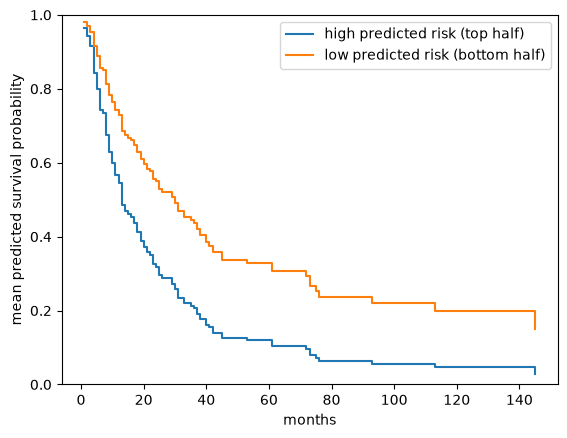

In [11]:
import matplotlib.pyplot as plt

high = risk > np.median(risk)
plt.step(cox.times_, S[high].mean(0), where="post", label="high predicted risk (top half)")
plt.step(cox.times_, S[~high].mean(0), where="post", label="low predicted risk (bottom half)")
plt.xlabel("months")
plt.ylabel("mean predicted survival probability")
plt.ylim(0, 1)
plt.legend()
plt.show()

## Options and tips

- **Checkpoints.** Three pretrained seeds ship with the package. The variance between the checkpoints is tiny. 
  The default is seed 0, but you can still pick another one with
  `from geneicl import CKPT` and `GeneICL(mode=..., ckpt=CKPT.with_name("trm_segmented8_s1.pt"))` if you want a more robust performance estimate for benchmarking.
- **Test-time ensemble.** `GeneICL(mode=..., ensemble_seed=1)` averages 8 seeded support views x 3 internal PCA
  thresholds (24 forward passes per predict, no labels used). The default `ensemble_seed=None` is one forward pass.
  It sometimes helps, but the benefit is generally small and not consistent across tasks, metrics or seeds (see
  the ensemble cells in sections 2 and 3), so the single forward pass is a good default.
- **Device.** `GeneICL(mode=..., device="cpu")` or `device="cuda"`. The default is the GPU when one is available.
- **Support-set size.** GeneICL was pretrained on synthetic tasks of 32 to 1024 samples. Larger support sets still run, but
  they are outside that range and we cannot guarantee the same performance.
- **Genes.** The model does not use gene names, only the columns: keep the same genes in the same order for the
  support set and the new samples.
- **Scale.** Input must be log1p-CPM; `fit` warns when the values look like raw counts.
- **Classes.** At most 10 classes per classification task.